# Kilonova Toy Model


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.integrate import solve_ivp

In [2]:
# Constants

CONST_C =  2.99792458e10 # [cm / s]
CONST_H = 6.6260755e-27  # Plank constant [erg s]
CONST_KB =  1.3806e-16   # Boltzmann constant [erg / K]
CONST_SB = 5.670374419e-5 # Stefan Boltzmann constant [erg cm^-2 s^-1 K^-4]

# Unit conversion

Msun2g = 1.989e33 # [Msun/ g]
c2cgs = CONST_C
day2sec = 86400.0 # [day / s]
mpc2cm = 3.085677581e24 # [Mpc / cm]

# Parameters

M_tot = 0.01   # in solar masses
v_min = 0.1    # in speed of light units
pl_index = 3.0
k0 = 20.0 # cm^2 / g
D = 100 # Mpc

# Thermalization parameters

a_therm, b_therm, d_therm = 0.56, 0.17, 0.74


# Filters parameters

lambda_c = np.array([365, 445, 551, 658, 806, 1220, 1630, 2190]) # UBVRIJHK [nm]

In [3]:
def tpeak(Mtot, vmin, k):

  # This function estimate the peak time of the kilonova
  # All inputs in cgs
  # output in s

  return(np.sqrt(k * Mtot /(4 * np.pi * vmin * CONST_C)))

def MassDistribution(v, Mtot, pl_index):

  # This function generate a cumulative mass power-law distribution
  # i.e. the mass with velocity > v
  #
  # Input:
  #
  #   v = velocity array from v_min to v_max
  #   Mtot = Total mass in the ejecta
  #   pl_index = power law index, positive defined -> negative slope

  vmin = np.min(v)
  M = Mtot * (v/vmin)**(-pl_index)

  return(M)

def diffusion_timescale(vmin, Mv, kv, pl_index, time):

  # This function calculate the diffiusion timescale at a given time
  # for the shell with velocity v
  # All input quantities in cgs
  # Input:
  #
  #   vmin = minimum velocity
  #   Mv = Mass with speed > v
  #   pl_index = power law index, positive defined -> negative slope
  #   time = time

  Mtot = Mv[0]

  tdef = ( Mv ** (1.0 - 1./pl_index) *  (Mtot**(1.0/pl_index)) * kv ) / (4.0 * np.pi * (vmin) * time * CONST_C)

  return tdef


def specific_radioactive_heating_rate(time):

  # This function calculate the specific radioactive heating rate with the Korobkin+2012 fitting formula

  const = 4e18
  eps_therm = 1.0
  t0 = 1.3 # [s]
  sigma = 0.11 # [s]


  heat = const*eps_therm * (0.5 - (1.0/np.pi)*np.arctan((time - t0)/sigma))**1.3 # [erg/s/g]

  return(heat)

def radioactive_heating_rate(time, dMv, Xr):

  # This function calculate the radioactive heating rate
  #
  # INPUT:
  #
  # time = time
  # dMv = cell mass
  # Xr = lanthanide fraction <= 1.0

  eps_r = specific_radioactive_heating_rate(time)

  heat = dMv * Xr * eps_r # [erg/s]

  return(heat)

def luminosity(Ev, tdiffv, tlcv):

  # This function calculate the bolometric luminosity of the shell
  #
  # INPUT:
  #
  # Ev = internal energy in v shell
  # tdiffv = diffusion time
  # tlcv = light crossing time

  Lv = Ev / (tdiffv + tlcv)

  return(Lv)

def adiabatic_loss(Ev, time):

  # This function calculate the adiabatic loss in the shell
  #
  # INPUT:
  #
  # Ev = internal energy in the v shell
  # time = time

  loss = - Ev / time

  return(loss)

def dE_dt(time, Ev, v_in, Mv_in, kv, Xr, pl_index):

  # This function calculate the RHS of the energy balance equation
  #
  # INPUT:
  #
  # time = time
  # Ev = Ev
  # v_in = velocity array in C units
  # Mv_in = mass array in solar mass units
  # kv = opacity
  # Xr = lanthanide fraction
  # pl_index = cumulative mass power law index

  # Convert in cgs the input quantities

  Mv = Mv_in * Msun2g
  v = v_in * c2cgs



  time = max(time, 1e-10) # Protect for time = 0

  # Calculate the mass and velocity in the shell

  vc = 0.5*(v[1:] + v[:-1])           # defined on the centers
  dMv = np.flip(np.diff(np.flip(Mv))) # defined on the centers
  vmin = v[0]


  tdiffv = diffusion_timescale(vmin, Mv, kv, pl_index, time) #[s] #defined on the node
  tdiff_c = 0.5 * (tdiffv[1:] + tdiffv[:-1]) #[s] #defined on the centers

  tlcv = vc * time / CONST_C # [s]
  Lv = luminosity(Ev, tdiff_c, tlcv) # [erg / s]
  loss = adiabatic_loss(Ev, time) # [erg / s]
  heat = radioactive_heating_rate(time, dMv, Xr) # [erg / s]

  return(heat + loss - Lv)



def optical_depth(time, vc, dMv, kv):

  # This function calculate the optical depth from the
  # outside to the inside
  #
  # INPUT:
  #
  # time = time
  # vc = velocity at the center of the cell
  # dMv = cell mass
  # kv = opacity


  kvc = 0.5 * (kv[1:] + kv[:-1])
  dtau = kvc * dMv / (4.0 * np.pi * (vc * time)**2)

  return(np.flip(np.cumsum(np.flip(dtau))))


def photosphere(time, vc, tau):

  # This function finds the radius of the photosphere, when the
  # tau = 1
  #
  # INPUT:
  #
  # time = time
  # vc = velocity at the center of the cell
  # tau = optical depth from outside to the inside

  idx = np.searchsorted(-tau, -1.0) # minus sign because tau decreases

  if idx >= len(vc):
    v_photo = vc[-1] # all the ejecta optically thick
  elif idx == 0:
    v_photo = vc[0] # all the ejecta optically thin
  else:
    # linear interpolation
    tau1, tau2 = tau[idx-1], tau[idx]
    v1, v2 = vc[idx-1], vc[idx]
    v_photo = v1 + (1.0 - tau1) / (tau2 - tau1) * (v2 - v1)

  R_photo = v_photo * time


  return(R_photo)


def T_effective(L_bol, R_photo):

  # This function applies the Stefan-Boltzmann law to calculate the
  # effective temperature
  #
  # INPUT:
  #
  # L_bol = bolometric luminosity
  # R_photo = Photospheric radius

  return (L_bol / (4 * np.pi * R_photo**2 * CONST_SB))**(1.0/4.0)


def Fnu_BB(nu, R_phot, T_eff, D):

  # This function calculates the specific flux (BB)
  # given the photosphere radius and the effective time
  #
  # INPUT:
  #
  # nu = frequency
  # R_phot = photosphere radius
  # T_eff = effective temperature
  # D = source distance

  const = 2 * np.pi * CONST_H / CONST_C**2

  dist_scale = (R_phot / D)**2

  x = CONST_H * nu / CONST_KB / T_eff

  return(const * nu**3 / np.expm1(x) * dist_scale)

def Flux2ABmag(Fnu):


  # This function convert the specific flux in AB magnitudes
  #
  # INPUT:
  #
  # Fnu = specific flux
  #

  return (-2.5*np.log10(Fnu) - 48.60)




In [ ]:
# Allocate the velocity and Mass distribution array

vmax = 0.3

v = np.linspace(v_min, vmax, 100)

M = MassDistribution(v, M_tot, pl_index)


## Exercise: plot v vs M

In [ ]:
# Put here your code

In [5]:
# Define the velocity at shell center and mass in each shell

vc = 0.5*(v[1:] + v[:-1])
Mshell = np.flip(np.diff(np.flip(M)))

print(np.sum(Mshell) - M_tot) # check total mass ~ Mtot (should be slightly less)


-0.0003703703703703716


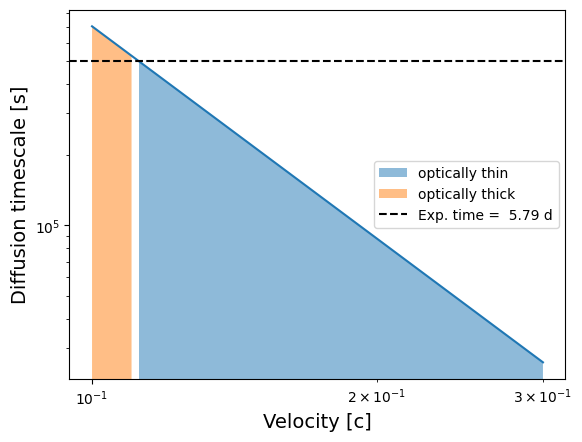

In [6]:
# Assign diffusion timescale
time = 5e5

kv = np.full_like(v, k0) # assign opacity

tdiffv = diffusion_timescale(v * c2cgs, M * Msun2g, kv, pl_index, time) # calculate diffusione time

# find the optically thin shell

opt_thin = np.where(tdiffv < time)
v_thin = v[opt_thin]
tdiffv_thin = tdiffv[opt_thin]
opt_thick = np.where(tdiffv >= time)
v_thick = v[opt_thick]
tdiffv_thick = tdiffv[opt_thick]




plt.plot(v, tdiffv)
plt.fill_between(v_thin, tdiffv_thin, 0, alpha = 0.5, label = 'optically thin')
plt.fill_between(v_thick, tdiffv_thick, 0, alpha = 0.5, label = 'optically thick')
plt.axhline(time, linestyle = 'dashed',
            color = 'k', label = 'Exp. time = % .2f d' % (time / (3600 * 24)))
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Velocity [c]', fontsize = 14)
plt.ylabel('Diffusion timescale [s]', fontsize = 14)
plt.legend()

plt.show()

# Exercise: use trial and error to find when the ejecta starts becoming optically thin and when it is completely optically thin

In [7]:
# Initialize the systhem


t0 = 0.0002 * day2sec
t1 = 50.0 * day2sec
t_span = (t0, t1)

Ev0 =  0.5*(Mshell*Msun2g)*(vc*c2cgs)**2 # Equipartition initial condition
#Ev0 = 0.0 * Ev0                         # 0 internal energy initial condition


t_eval = np.logspace(np.log10(t0), np.log10(t1), 500)
t_eval = np.clip(t_eval, t0, t1)

# Solve the Energy Balance ODE

sol = solve_ivp(
    fun = dE_dt,
    t_span = t_span,
    t_eval = t_eval,
    y0 = Ev0,
    args = (v, M, kv, 1.0, pl_index),
    method = 'RK45'
)

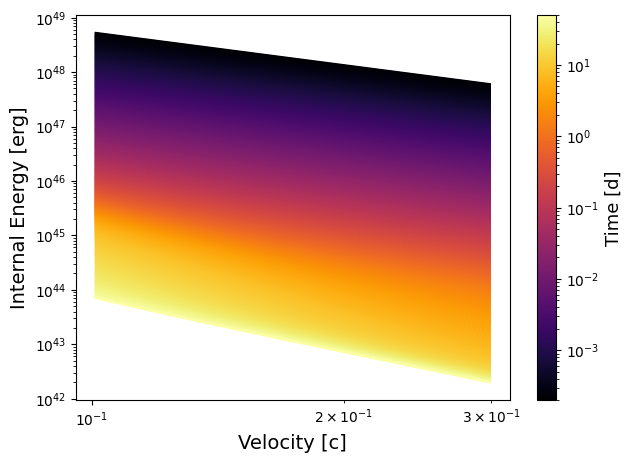

In [8]:
# Solution diagnostic

fig, ax = plt.subplots(figsize = (7, 5))

cmap = plt.cm.inferno
norm = mpl.colors.LogNorm(vmin = t_eval.min()/day2sec, vmax = t_eval.max()/day2sec)

for index_time, t in enumerate(t_eval):
  color = cmap(norm(t/day2sec))
  ax.plot(vc, sol.y[:,index_time], color = color, lw = 1.2)
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Velocity [c]', fontsize = 14)
ax.set_ylabel('Internal Energy [erg]', fontsize = 14)

sm = mpl.cm.ScalarMappable(norm = norm, cmap = cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax = ax)
cbar.set_label('Time [d]', fontsize = 13)

plt.show()

In [ ]:
# Calculate the luminosity

L_bol = np.zeros_like(t_eval)

for index_time, t in enumerate(t_eval):

  Mcgs = M * Msun2g
  vc_cgs = 0.5*(v[1:] + v[:-1]) * c2cgs

  vmin = np.min(v) * c2cgs
  tdiffv = diffusion_timescale(vmin, Mcgs, kv, pl_index, t) #[s] #defined on the node
  tdiff_c = 0.5 * (tdiffv[1:] + tdiffv[:-1]) #[s] #defined on the centers

  tlcv = vc_cgs * t / CONST_C# [s]
  Lv = luminosity(sol.y[:,index_time], tdiff_c, tlcv) # [erg / s]

  L_bol[index_time] = np.sum(Lv)




## Excercise: Plot the bolometric lightcurve

In [ ]:
# Put here your code

In [10]:
# Find the photosphere

R_phot = np.zeros_like(t_eval) # Initialize the photosphere array

# Calculate tau
for index_time, t in enumerate(t_eval):

  tau = optical_depth(t, vc*c2cgs, Mshell*Msun2g, kv)

  R_phot[index_time] = photosphere(t, vc*c2cgs, tau)


T_eff = T_effective(L_bol, R_phot)

## Exercise: Plot the photospheric radius, the internal radius and the external radius vs time

In [ ]:
# Put here your code

## Excerise: Plot the effective temperature vs time

In [ ]:
# Put here your code

In [13]:
# Unpack frequencies

nu_c = CONST_C / (lambda_c * 1e-7)

Flux = np.zeros((len(t_eval), len(lambda_c)))

for index_nu, nu in enumerate(nu_c):
  Flux[:, index_nu] = Fnu_BB(nu, R_phot, T_eff, D * mpc2cm)


In [ ]:
# Put here your code

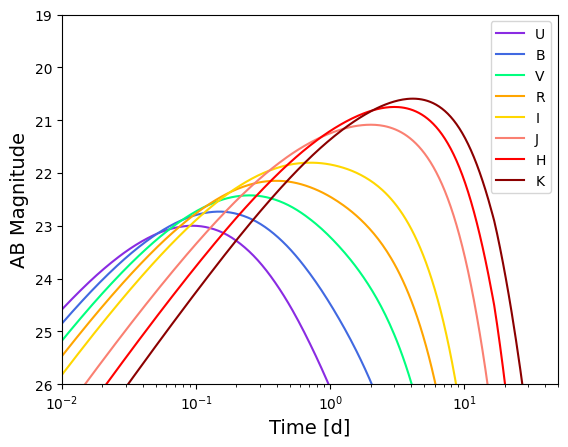

In [14]:
# Convert Flux in magnitude

mag = Flux2ABmag(Flux)

label = ["U", "B", "V", "R", "I", "J", "H", "K"]
color = ['blueviolet', 'royalblue', "springgreen", "orange", "gold", "salmon", "red", "darkred"]

for index_nu, nu in enumerate(nu_c):
  plt.plot(t_eval / day2sec, mag[:, index_nu], label = label[index_nu], color = color[index_nu])

plt.xscale('log')
#plt.yscale('log')


plt.gca().invert_yaxis()

plt.xlim(0.01, 50)
plt.ylim(26, 19)

plt.xlabel('Time [d]', fontsize = 14)
plt.ylabel('AB Magnitude', fontsize = 14)

plt.legend()